# Assignment 8

## Question 1

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

### A. Load the data

In [46]:
FENCE_DIR = "../Ass7/fence_renamed"

inside_paths = [os.path.join(FENCE_DIR, "inside", f) for f in os.listdir(os.path.join(FENCE_DIR, "inside"))  if f.endswith(".jpg")]
outside_paths = [os.path.join(FENCE_DIR, "outside", f) for f in os.listdir(os.path.join(FENCE_DIR, "outside")) if f.endswith(".jpg")]

print(f"Inside images: {len(inside_paths)}")
print(f"Outside images: {len(outside_paths)}")

Inside images: 467
Outside images: 524


#### Balance the binary dataset

In [47]:
n_samples = min(len(inside_paths), len(outside_paths))
inside_paths = inside_paths[:n_samples]
outside_paths = outside_paths[:n_samples]
print(f"Balanced: {n_samples} per class, {n_samples * 2} total")

Balanced: 467 per class, 934 total


### B. Preprocess images

In [ ]:
IMG_SIZE = (64, 64)

def augment_single(img):
    return [
        img,
        np.flip(img, axis=1), # horizontal flip
        np.flip(img, axis=0), # vertical flip
        np.rot90(img, k=1), # 90-degree rotation
    ]

original_images = []
images = []
labels_list = []

all_paths = inside_paths + outside_paths
all_labels_raw = [0] * len(inside_paths) + [1] * len(outside_paths)

for p, lbl in zip(all_paths, all_labels_raw):
    original = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    original_images.append(original)

    for aug_img in augment_single(original):
        resized = cv2.resize(aug_img, IMG_SIZE)
        images.append(resized)
        labels_list.append(lbl)

images = np.array(images, dtype="float32") / 255.0
images = images[..., np.newaxis]  # (N, 64, 64, 1)

labels = np.array(labels_list, dtype="float32")
print(f"Original images: {len(original_images)}")
print(f"After augmentation & resize: Images shape: {images.shape}, Labels shape: {labels.shape}")

Original images: 934
After augmentation & resize: Images shape: (3736, 64, 64, 1), Labels shape: (3736,)


#### Split into train, validation, and test sets

In [49]:
train_data, temp_data, train_labels, temp_labels = train_test_split(
    images, labels, test_size=0.30, random_state=42, stratify=labels
)
val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"Training Data: {len(train_data)}")
print(f"Validation Data: {len(val_data)}")
print(f"Testing Data: {len(test_data)}")

Training Data: 2615
Validation Data: 560
Testing Data: 561


#### Visualize sample images

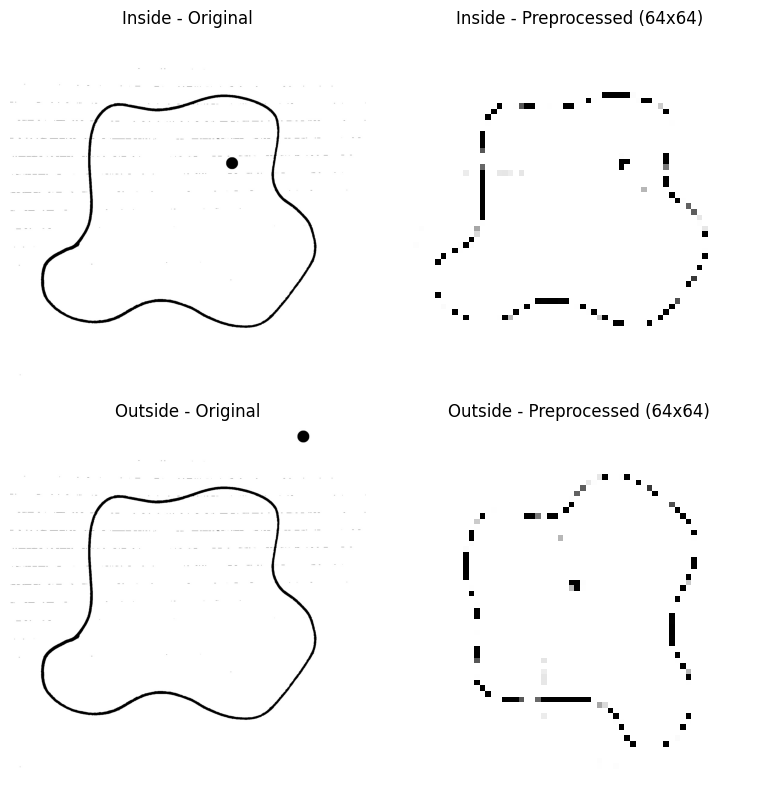

In [50]:
inside_idx = 0
outside_idx = len(inside_paths)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(original_images[inside_idx], cmap="gray")
axes[0, 0].set_title("Inside - Original")
axes[0, 0].axis("off")
axes[0, 1].imshow(images[inside_idx, ..., 0], cmap="gray")
axes[0, 1].set_title(f"Inside - Preprocessed ({IMG_SIZE[0]}x{IMG_SIZE[1]})")
axes[0, 1].axis("off")
axes[1, 0].imshow(original_images[outside_idx], cmap="gray")
axes[1, 0].set_title("Outside - Original")
axes[1, 0].axis("off")
axes[1, 1].imshow(images[outside_idx, ..., 0], cmap="gray")
axes[1, 1].set_title(f"Outside - Preprocessed ({IMG_SIZE[0]}x{IMG_SIZE[1]})")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

#### Build the CNN Model

In [51]:
cnn_model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [52]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    min_delta=1e-4,
    restore_best_weights=True,
)

history_cnn = cnn_model.fit(
    train_data, train_labels,
    epochs=80,
    validation_data=(val_data, val_labels),
    callbacks=[early_stop],
    verbose=1,
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(test_data, test_labels, verbose=0)
print(f'CNN Test accuracy: {cnn_test_acc:.4f}')

Epoch 1/80
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5123 - loss: 0.7068

2026-03-26 19:11:45.521997: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-26 19:11:45.548142: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,32,31,31]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5126 - loss: 0.7067

2026-03-26 19:11:47.293435: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-26 19:11:47.311575: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,31,31]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5323 - loss: 0.6961 - val_accuracy: 0.7054 - val_loss: 0.6887
Epoch 2/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6073 - loss: 0.6646 - val_accuracy: 0.8393 - val_loss: 0.5791
Epoch 3/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8750 - loss: 0.3981 - val_accuracy: 0.9411 - val_loss: 0.2332
Epoch 4/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9602 - loss: 0.1530 - val_accuracy: 0.9696 - val_loss: 0.1188
Epoch 5/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9652 - loss: 0.1050 - val_accuracy: 0.9696 - val_loss: 0.0981
Epoch 6/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9744 - loss: 0.0783 - val_accuracy: 0.9714 - val_loss: 0.0866
Epoch 7/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9728 - loss: 0.0729 - val_accuracy: 0.9661 - val_loss: 0.0986
Epoch 8/80
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9767 - loss: 0.0633 - val_accuracy: 0.9732 - val_loss: 0.0709
Ep

2026-03-26 19:12:29.345516: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[17,32,62,62]{3,2,1,0}, u8[0]{0}) custom-call(f32[17,1,64,64]{3,2,1,0}, f32[32,1,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-26 19:12:29.365609: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[17,64,29,29]{3,2,1,0}, u8[0]{0}) custom-call(f32[17,32,31,31]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationFor

CNN Test accuracy: 0.9893


### C. Evaluate Performance

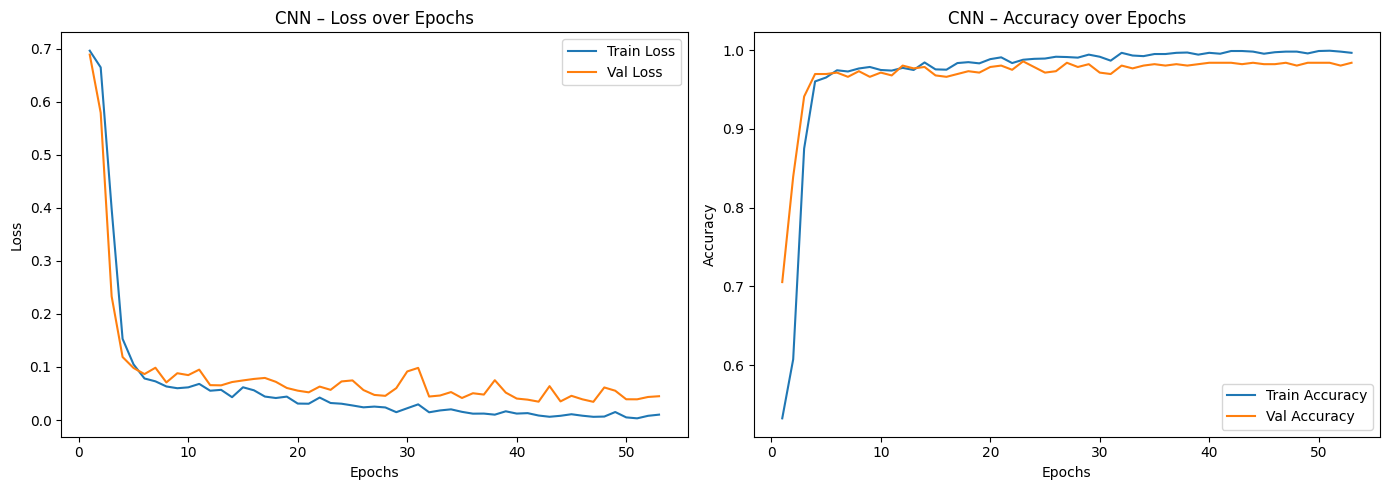

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history_cnn.history['loss']) + 1)
ax1.plot(epochs, history_cnn.history['loss'], label='Train Loss')
ax1.plot(epochs, history_cnn.history['val_loss'], label='Val Loss')
ax1.set_title('CNN – Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history_cnn.history['accuracy'], label='Train Accuracy')
ax2.plot(epochs, history_cnn.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('CNN – Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

#### Confusion Matrix and Metrics on Test Data

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


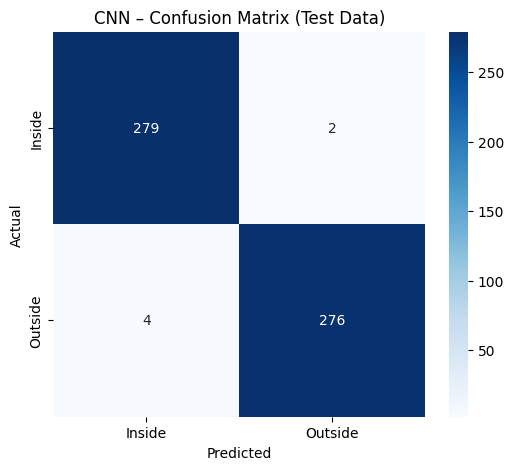

Accuracy: 0.9893
Precision: 0.9928
Recall: 0.9857
F1 Score: 0.9892


In [54]:
y_pred_cnn = cnn_model.predict(test_data)
y_pred_cnn = (y_pred_cnn > 0.5).astype(int).flatten()

cm = confusion_matrix(test_labels, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Inside', 'Outside'],
            yticklabels=['Inside', 'Outside'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('CNN – Confusion Matrix (Test Data)')
plt.show()

accuracy = accuracy_score(test_labels, y_pred_cnn)
precision = precision_score(test_labels, y_pred_cnn)
recall = recall_score(test_labels, y_pred_cnn)
f1 = f1_score(test_labels, y_pred_cnn)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

## Conclusion
FCN Results:

- Accuracy: 0.9291
- Precision: 0.9286
- Recall: 0.9286
- F1 Score: 0.9286

CNN Results:
- Accuracy: 0.9893
- Precision: 0.9928
- Recall: 0.9857
- F1 Score: 0.9892

We clearly see the CNN outperforms the FCN by alot

plus the data augmentation helps the model generalize better.

---

## Question 2

### Load and visualize MNIST data

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


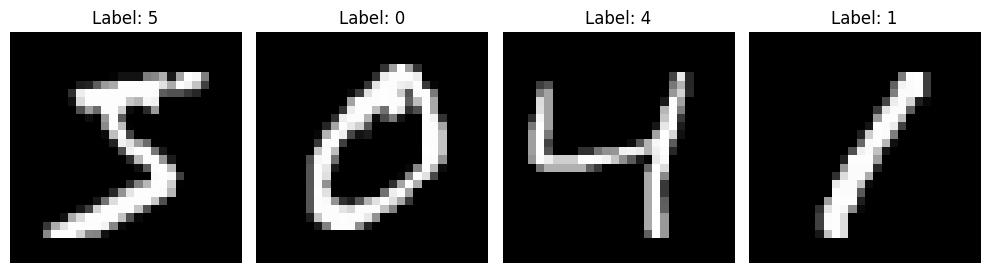

In [55]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test  = x_test / 255.0

print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for i in range(4):
    axes[i].imshow(x_train[i], cmap="gray")
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Reshape for CNN 

In [56]:
x_train_cnn = x_train[..., np.newaxis]
x_test_cnn= x_test[..., np.newaxis]
print(f"CNN Training shape: {x_train_cnn.shape}")
print(f"CNN Testing shape: {x_test_cnn.shape}")

CNN Training shape: (60000, 28, 28, 1)
CNN Testing shape: (10000, 28, 28, 1)


### FCN Architecture (from Assignment 6)

In [57]:
fcn_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

fcn_model.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/home/ardo/mlem/Study/Sem8/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
history_fcn = fcn_model.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test),
    verbose=1
)

fcn_test_loss, fcn_test_acc = fcn_model.evaluate(x_test, y_test, verbose=0)
print(f'FCN Test accuracy: {fcn_test_acc:.4f}')

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9128 - loss: 0.3091 - val_accuracy: 0.9441 - val_loss: 0.1835
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9536 - loss: 0.1595 - val_accuracy: 0.9616 - val_loss: 0.1334
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9652 - loss: 0.1211 - val_accuracy: 0.9623 - val_loss: 0.1241
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9709 - loss: 0.0984 - val_accuracy: 0.9683 - val_loss: 0.1074
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9759 - loss: 0.0836 - val_accuracy: 0.9689 - val_loss: 0.1100
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9789 - loss: 0.0749 - val_accuracy: 0.9718 - val_loss: 0.0975
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9811 - loss: 0.0667 - val_accuracy: 0.9750 - val_loss: 0.0918
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9832 - loss: 0.0614 - 

### CNN Model for MNIST

In [ ]:
mnist_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

mnist_cnn.compile(
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [60]:
history_mnist_cnn = mnist_cnn.fit(
    x_train_cnn, y_train,
    epochs=15,
    validation_data=(x_test_cnn, y_test),
    verbose=1
)

cnn_mnist_loss, cnn_mnist_acc = mnist_cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f'CNN Test accuracy: {cnn_mnist_acc:.4f}')

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9569 - loss: 0.1392 - val_accuracy: 0.9831 - val_loss: 0.0510
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9864 - loss: 0.0449 - val_accuracy: 0.9897 - val_loss: 0.0304
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9907 - loss: 0.0309 - val_accuracy: 0.9904 - val_loss: 0.0299
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9927 - loss: 0.0235 - val_accuracy: 0.9902 - val_loss: 0.0337
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9909 - val_loss: 0.0284
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9956 - loss: 0.0147 - val_accuracy: 0.9920 - val_loss: 0.0289
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0128 - val_accuracy: 0.9922 - val_loss: 0.0308
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9971 - loss: 0.0104 -

### Performance Comparison: FCN vs CNN on MNIST

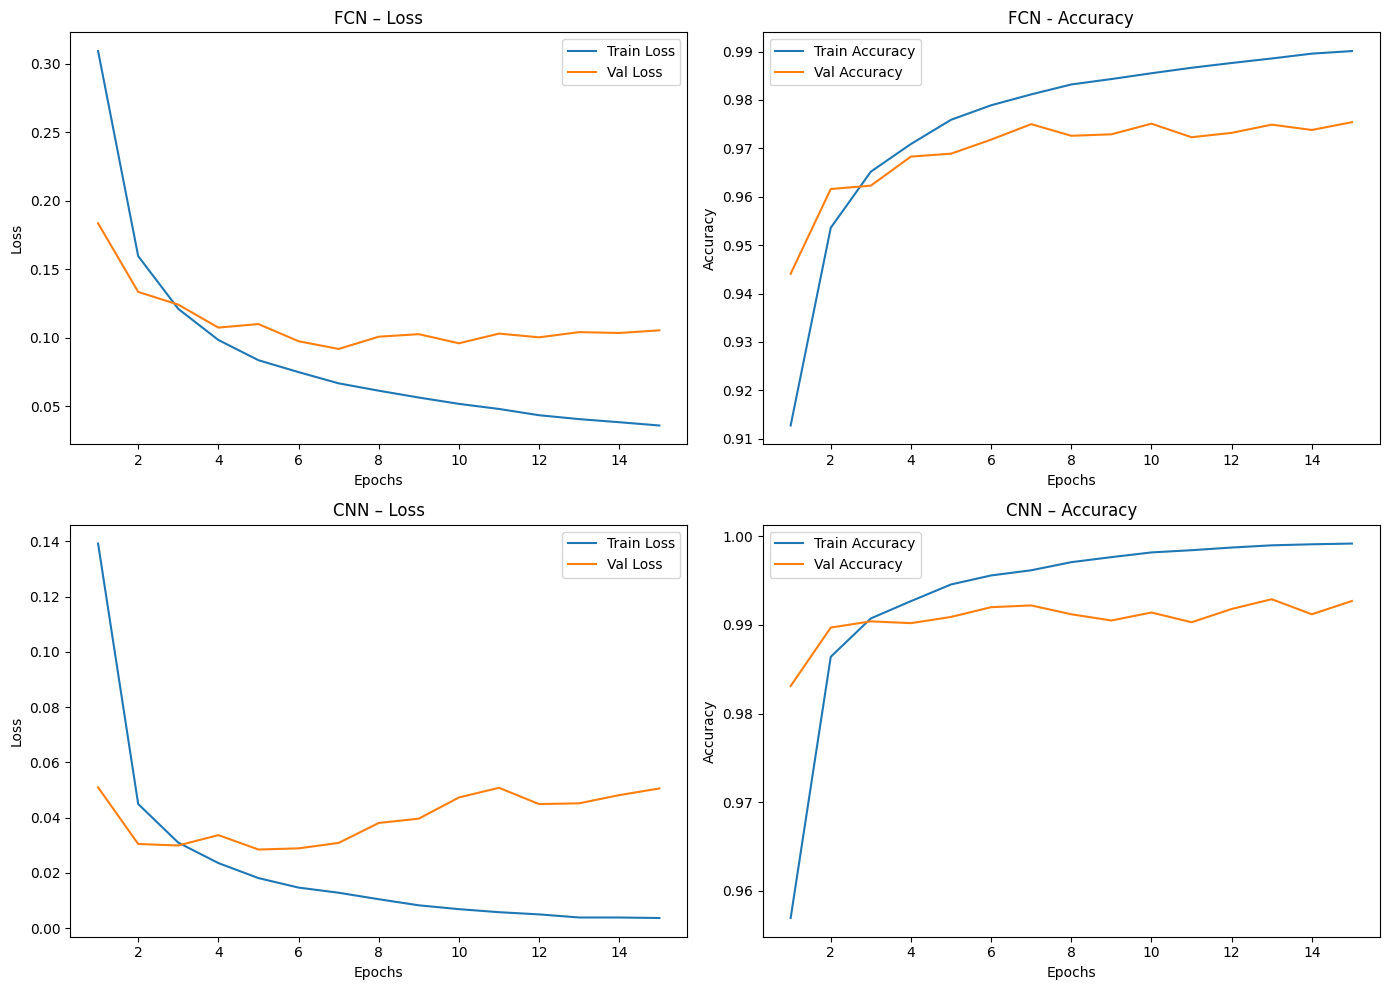

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FCN Loss
epochs_fcn = range(1, len(history_fcn.history['loss']) + 1)
axes[0, 0].plot(epochs_fcn, history_fcn.history['loss'], label='Train Loss')
axes[0, 0].plot(epochs_fcn, history_fcn.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('FCN – Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# FCN Accuracy
axes[0, 1].plot(epochs_fcn, history_fcn.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(epochs_fcn, history_fcn.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('FCN - Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# CNN Loss
epochs_cnn = range(1, len(history_mnist_cnn.history['loss']) + 1)
axes[1, 0].plot(epochs_cnn, history_mnist_cnn.history['loss'], label='Train Loss')
axes[1, 0].plot(epochs_cnn, history_mnist_cnn.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('CNN – Loss')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

# CNN Accuracy
axes[1, 1].plot(epochs_cnn, history_mnist_cnn.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(epochs_cnn, history_mnist_cnn.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('CNN – Accuracy')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


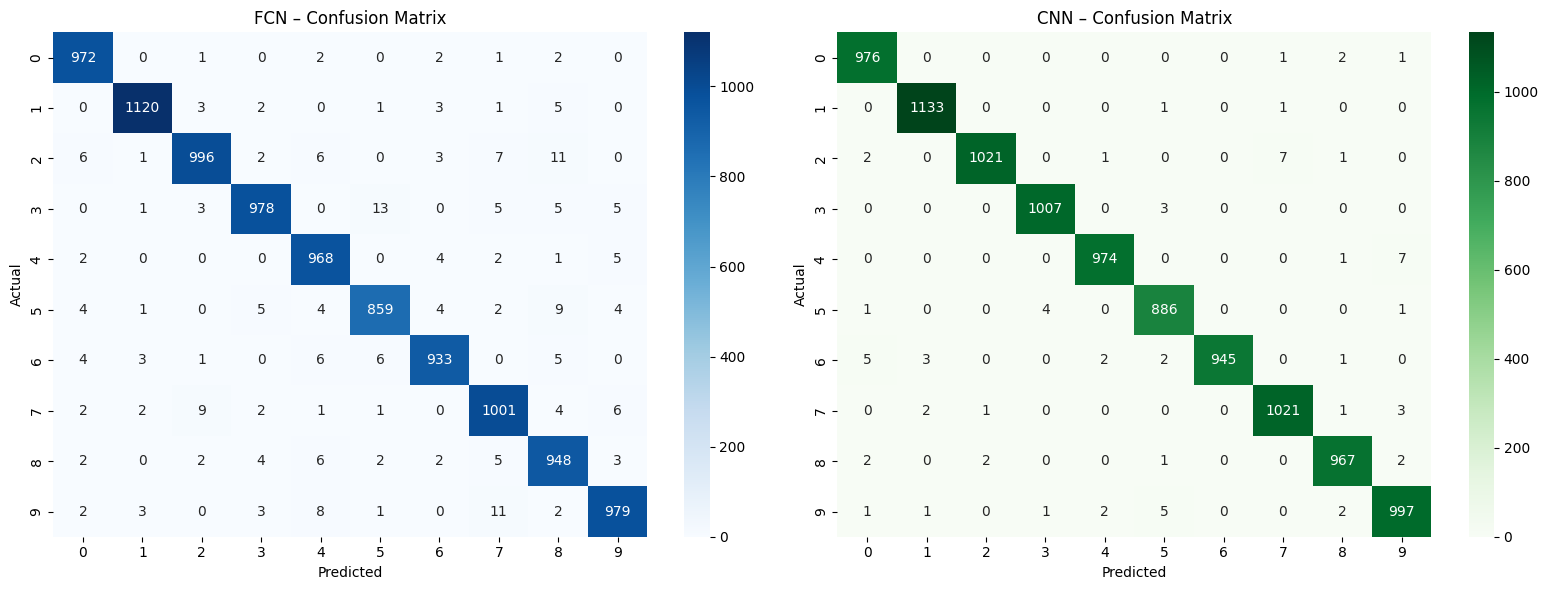

In [62]:
y_pred_fcn = fcn_model.predict(x_test)
y_pred_fcn = np.argmax(y_pred_fcn, axis=1)

y_pred_mnist_cnn = mnist_cnn.predict(x_test_cnn)
y_pred_mnist_cnn = np.argmax(y_pred_mnist_cnn, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cm_fcn = confusion_matrix(y_test, y_pred_fcn)
sns.heatmap(cm_fcn, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('FCN – Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

cm_cnn = confusion_matrix(y_test, y_pred_mnist_cnn)
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('CNN – Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [63]:
print("=" * 50)
print("MNIST Performance Comparison: FCN vs CNN")
print("=" * 50)
print(f"{'Metric'} {'FCN'} {'CNN'}")
print("-" * 35)
print(f"{'Test Loss: '} {fcn_test_loss:.4}, {cnn_mnist_loss:.4}")
print(f"{'Test Accuracy: '} {fcn_test_acc:.4}, {cnn_mnist_acc:.4}")

fcn_precision = precision_score(y_test, y_pred_fcn, average='weighted')
cnn_precision = precision_score(y_test, y_pred_mnist_cnn, average='weighted')
fcn_recall = recall_score(y_test, y_pred_fcn, average='weighted')
cnn_recall = recall_score(y_test, y_pred_mnist_cnn, average='weighted')
fcn_f1 = f1_score(y_test, y_pred_fcn, average='weighted')
cnn_f1 = f1_score(y_test, y_pred_mnist_cnn, average='weighted')

print(f"{'Precision: '} {fcn_precision:.4}, {cnn_precision:.4}")
print(f"{'Recall: '} {fcn_recall:.4}, {cnn_recall:.4}")
print(f"{'F1 Score: '} {fcn_f1:.4}, {cnn_f1:.4}")
print("=" * 50)

MNIST Performance Comparison: FCN vs CNN
Metric FCN CNN
-----------------------------------
Test Loss:  0.1054, 0.05056
Test Accuracy:  0.9754, 0.9927
Precision:  0.9755, 0.9927
Recall:  0.9754, 0.9927
F1 Score:  0.9754, 0.9927


We see CNN also performs better here as the numbered data set has geometrical structures that are better solved/learned via CNNs. As we get:

FCN Accuracy - 0.9749

CNN Accuracy - 0.9908